### In this notebook, we will learn to use PCA to reduce the dimensionality of the dataset along with preserving maximum information our dataset originally holds.
- This dataset is a classification type dataset having 784 Features each having the info of 1 pixel of the image in binary(0,1).
- This dataset has the info of the digits in the 28x28 pixels format 
- Target column named(label) tells us to what data of digit each row holds. There are total 42000 rows.

In [12]:
# plt.style.available

In [13]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")

In [6]:
#importing the dataset
df = pd.read_csv('train.csv')
print(df.head())

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [7]:
# Basic info about the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [8]:
# basic stats 
print(df.describe())

              label   pixel0   pixel1   pixel2   pixel3   pixel4   pixel5  \
count  42000.000000  42000.0  42000.0  42000.0  42000.0  42000.0  42000.0   
mean       4.456643      0.0      0.0      0.0      0.0      0.0      0.0   
std        2.887730      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
25%        2.000000      0.0      0.0      0.0      0.0      0.0      0.0   
50%        4.000000      0.0      0.0      0.0      0.0      0.0      0.0   
75%        7.000000      0.0      0.0      0.0      0.0      0.0      0.0   
max        9.000000      0.0      0.0      0.0      0.0      0.0      0.0   

        pixel6   pixel7   pixel8  ...      pixel774      pixel775  \
count  42000.0  42000.0  42000.0  ...  42000.000000  42000.000000   
mean       0.0      0.0      0.0  ...      0.219286      0.117095   
std        0.0      0.0      0.0  ...      6.312890      4.633819   
min        0.0      0.0      0

In [20]:
df.isnull().sum().sum() # This shows there are no null values in entire dataset

np.int64(0)

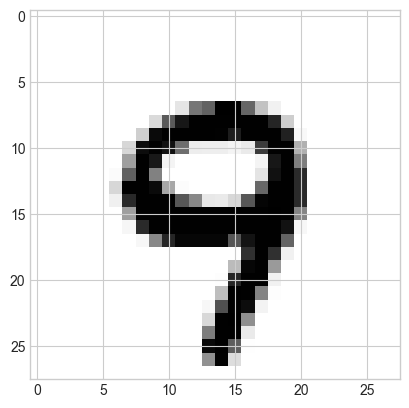

In [ ]:
# Let us see how the image is formed by using the columns as one pixel each
plt.imshow(df.iloc[11111,1:].values.reshape(28,28)) # see this row contains the info of Number 9

In [ ]:
# Let us look at the distribution of Target variable
(df['label'].value_counts()/42000)*100 # we see that the distribution is almost even

label
1    11.152381
7    10.478571
3    10.359524
9     9.971429
2     9.945238
6     9.850000
0     9.838095
4     9.695238
8     9.673810
5     9.035714
Name: count, dtype: float64

<Axes: xlabel='label'>

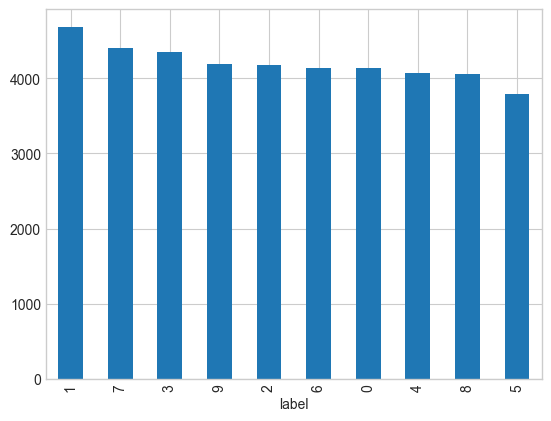

In [ ]:
df['label'].value_counts().plot(kind='bar') 

### There is no uneven distribution b/w the categories

### Firstly train the classification model without using PCA and check the accuracy score

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score , StratifiedKFold

# prepare the data by splitting features and Target data
X = df.iloc[:,1:]
y = df.iloc[:,0]

print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


In [34]:
# using cross-validation with stratify
knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)
scores = cross_val_score(knn , X,y ,scoring='accuracy' , cv = cv)

print('Scores After 5 fold cross-validation with Stratify\n{scores}')

Scores After 5 fold cross-validation with Stratify
{scores}


In [ ]:
print(np.mean(scores)) # So we are getting mean score of 96.69% which is actually great!!

0.966952380952381


### ***Performing Dimensionality Reduction using PCA***

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

scale = StandardScaler()

pca = PCA(n_components=X.shape[1])

knn = KNeighborsClassifier()

pipe = Pipeline(steps=[
    ('scale' , scale),
    ('pca' , pca),
    ('knn' , knn)
])

cv = StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)
scores = cross_val_score(pipe , X,y ,scoring='accuracy' , cv = cv)

print(np.mean(scores))


0.9381190476190475


### ***Now this is a good piece of code, getting the accuracy of 93.8%***
- (i) But we used all the Features i.e no use of PCA done actually
- (ii) We initiated our objects like KNN, StandardScaler outside the pipeline (it is risky) Do it inside the pipeline ONLY
- (iii) We are using defualt values of our objects like KNN (k=3) , and pca(we used n_components = 784) but we should use Hyperparameter tuning

### ***Solution***

- (i) Use param_grid() to perform hyperparameter tuning
- (ii) Use gridsearchcv() to perform tuning and cross validation

### ***Better Code***

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps=[
    ('scale' , StandardScaler()),
    ('pca' , PCA()),
    ('knn' , KNeighborsClassifier())
])

cv = StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)

param_grid = {
    'pca__n_components':[0.85,0.90,0.95],
    'knn__n_neighbors':[3,5],
    'knn__metric':['euclidean','manhattan']
}

grid = GridSearchCV(pipe , param_grid , cv = cv , scoring='accuracy' , n_jobs=-1)

grid.fit(X,y)

print(f"Best parameters -> {grid.best_params_}")
print(f"Best Accuracy Score -> {grid.best_score_}")




Best parameters -> {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'pca__n_components': 0.85}
Best Accuracy Score -> 0.9501428571428571


### This result shows that the best parameters from the given parameters are these
- Next Step - We will now split the data using train_test_split and then fit the data with these best estimators

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=42)

best_model = grid.best_estimator_
best_model.fit(X_train,y_train)

y_pred_best = best_model.predict(X_test)

print(f'Test Accuracy -> {accuracy_score(y_test , y_pred_best)}')
print(f'Train Accuracy -> {accuracy_score(y_train , best_model.predict(X_train))}')

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

Test Accuracy -> 0.9508333333333333
Train Accuracy -> 0.9651488095238095
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       816
           1       0.96      0.99      0.98       909
           2       0.96      0.94      0.95       846
           3       0.94      0.94      0.94       937
           4       0.97      0.95      0.96       839
           5       0.93      0.93      0.93       702
           6       0.96      0.97      0.96       785
           7       0.96      0.94      0.95       893
           8       0.96      0.92      0.94       835
           9       0.93      0.93      0.93       838

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400



### We see that f1-score is 0.95 which is good result -> Also train accuracy > test accuracy showing that model did not overfit 

### Viewing the Diagram of the Fitting

In [41]:
from sklearn import set_config
set_config(display='diagram')

# Just run this in a Jupyter cell — renders an interactive diagram
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",0.85
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', '